In [108]:
from pyod.utils.data import generate_data_clusters
from matplotlib import pyplot as plt
import numpy as np

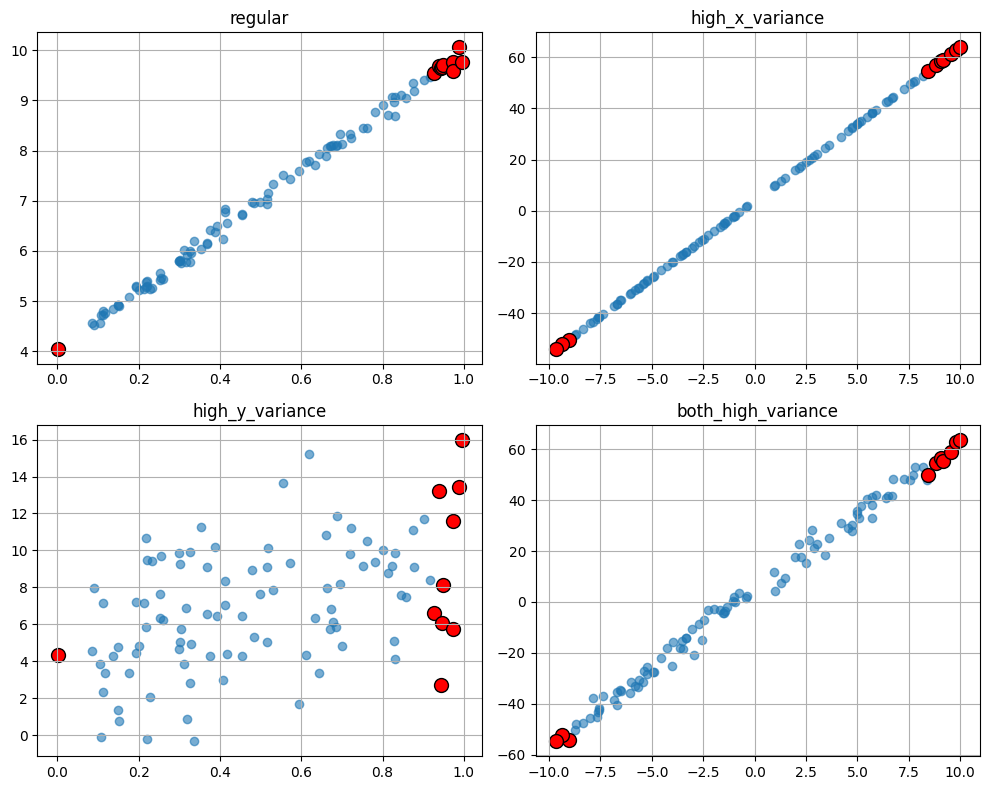

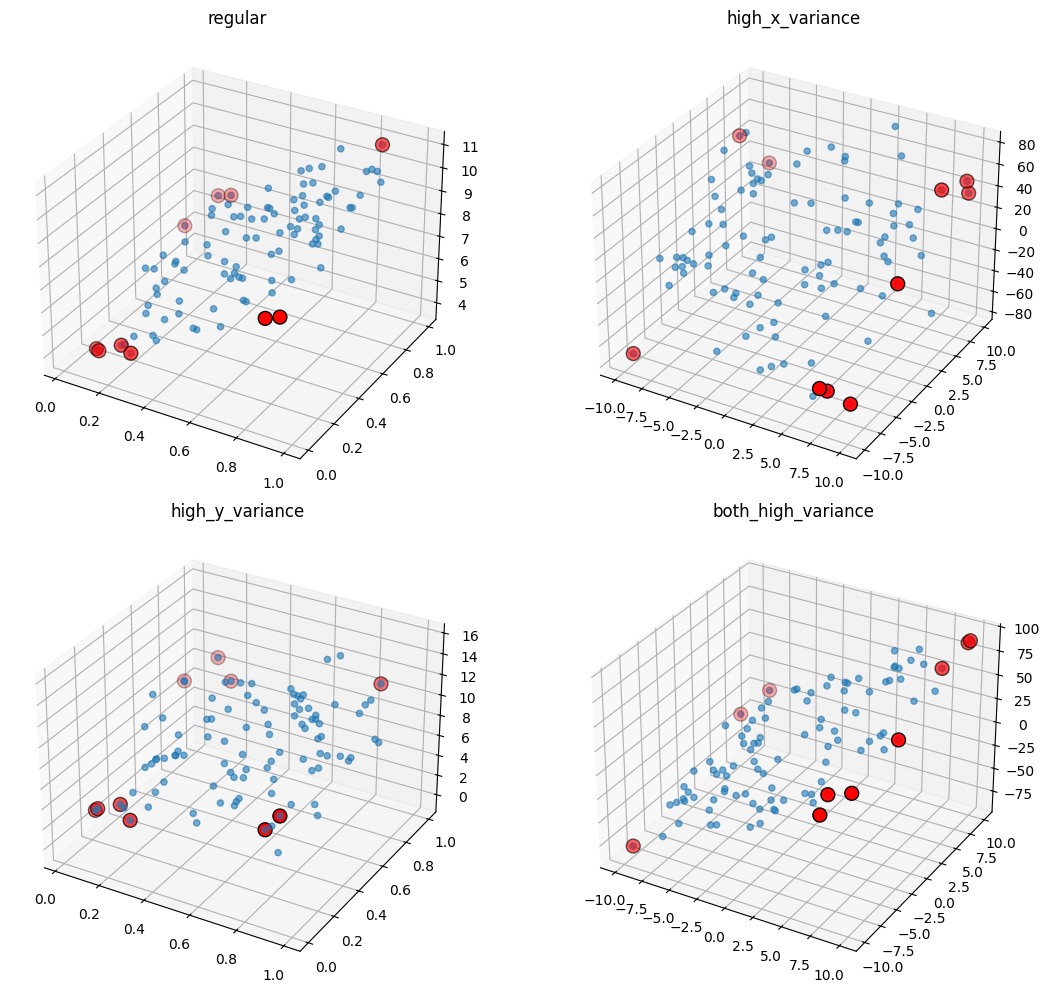

In [109]:
# Ex 1:
# 1 dimensional case:
a = 6
b = 3
mu = 1
sigma = 0.1

# regular points
x_regular = np.random.rand(100)
epsilon_regular = np.random.normal(mu, sigma, 100)
y_regular = a * x_regular + b + epsilon_regular

# high x variance points
x_highx_var = np.random.uniform(-10, 10, 100)
y_highx_var = a * x_highx_var + b + epsilon_regular

# high y variance points
epsilon_highy_var = np.random.normal(mu, 3, 100)
y_highy_var = a * x_regular + b + epsilon_highy_var

# high x variance and high y variance points
y_highx_highy_var = a * x_highx_var + b + epsilon_highy_var

to_plot = {'regular' : (x_regular, y_regular), 'high_x_variance': (x_highx_var, y_highx_var), 'high_y_variance': (x_regular, y_highy_var), 'both_high_variance': (x_highx_var, y_highx_highy_var)}
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, (title, (x, y)) in enumerate(to_plot.items()):
    ax = axes[i // 2, i % 2]
    X = np.vstack([x, np.ones(len(x))]).T
    H = X @ np.linalg.inv(X.T @ X) @ X.T
    leverage_scores = np.diag(H)
    high_leverage_indices = np.argsort(leverage_scores)[-10:]

    ax.scatter(x, y, alpha=0.6, label='Data Points')
    ax.grid()
    ax.scatter(
        x[high_leverage_indices],
        y[high_leverage_indices],
        color='red',
        edgecolor='black',
        s=100,
        label=f'Top {10} Leverage'
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

# 2 dimensional:
a = 6
b = 3
c = 2
mu = 1
sigma = 0.1


# regular points
x1_regular = np.random.rand(100)
x2_regular = np.random.rand(100)
epsilon_regular = np.random.normal(mu, sigma, 100)
y_regular = a * x1_regular + b * x2_regular + c + epsilon_regular

# high x variance points
x1_highx_var = np.random.uniform(-10, 10, 100)
x2_high_x_var = np.random.uniform(-10, 10, 100)
y_highx_var = a * x_highx_var + b * x2_high_x_var + c + epsilon_regular

# high y variance points
epsilon_highy_var = np.random.normal(mu, 3, 100)
y_highy_var = a * x1_regular + b * x2_regular + c + epsilon_highy_var

# high x variance and high y variance points
y_highx_highy_var = a * x1_highx_var + b * x2_high_x_var + c + epsilon_highy_var


to_plot = {'regular' : (x1_regular, x2_regular, y_regular), 'high_x_variance': (x1_highx_var, x2_high_x_var, y_highx_var), 'high_y_variance': (x1_regular, x2_regular, y_highy_var), 'both_high_variance': (x1_highx_var, x2_high_x_var, y_highx_highy_var)}
fig = plt.figure(figsize=(12, 10))

for i, (title, (x1, x2, y)) in enumerate(to_plot.items()):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    X = np.vstack([x1, x2, np.ones(len(x1))]).T
    H = X @ np.linalg.inv(X.T @ X) @ X.T
    leverage_scores = np.diag(H)
    high_leverage_indices = np.argsort(leverage_scores)[-10:]

    ax.scatter(x1, x2, y, alpha=0.6, label='Points')
    ax.grid()
    ax.scatter(
        x1[high_leverage_indices],
        x2[high_leverage_indices],
        y[high_leverage_indices],
        color='red',
        edgecolor='black',
        s=100,
        label=f'Top {10} Leverage'
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()



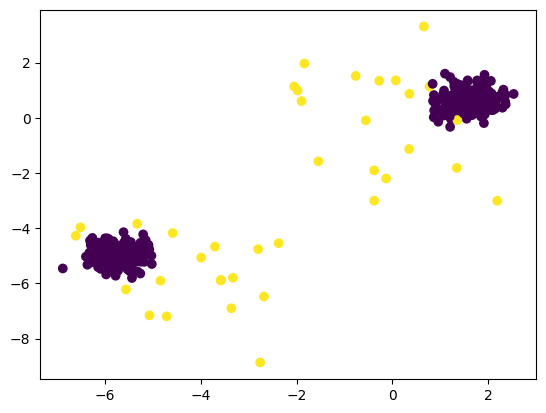

In [122]:
# Ex 2
# 2d dataset, 400 train 200 test, 2 clusters, 0.1 contamination
X_train, X_test, y_train, y_test = generate_data_clusters(n_features=2, n_clusters=2, n_train=400, n_test=200, contamination=0.1)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

In [124]:
from pyod.models.knn import KNN

knn = KNN()
knn.fit(X_train)

KNN(algorithm='auto', contamination=0.1, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [125]:
train_preds = knn.predict(X_train)
test_preds = knn.predict(X_test)
print(test_preds.shape)
from sklearn.metrics import balanced_accuracy_score

bac = balanced_accuracy_score(y_train, train_preds)
print(bac)
bac = balanced_accuracy_score(y_test, test_preds)
print(bac)

(200,)
0.9823542550815278
0.9045689019896832


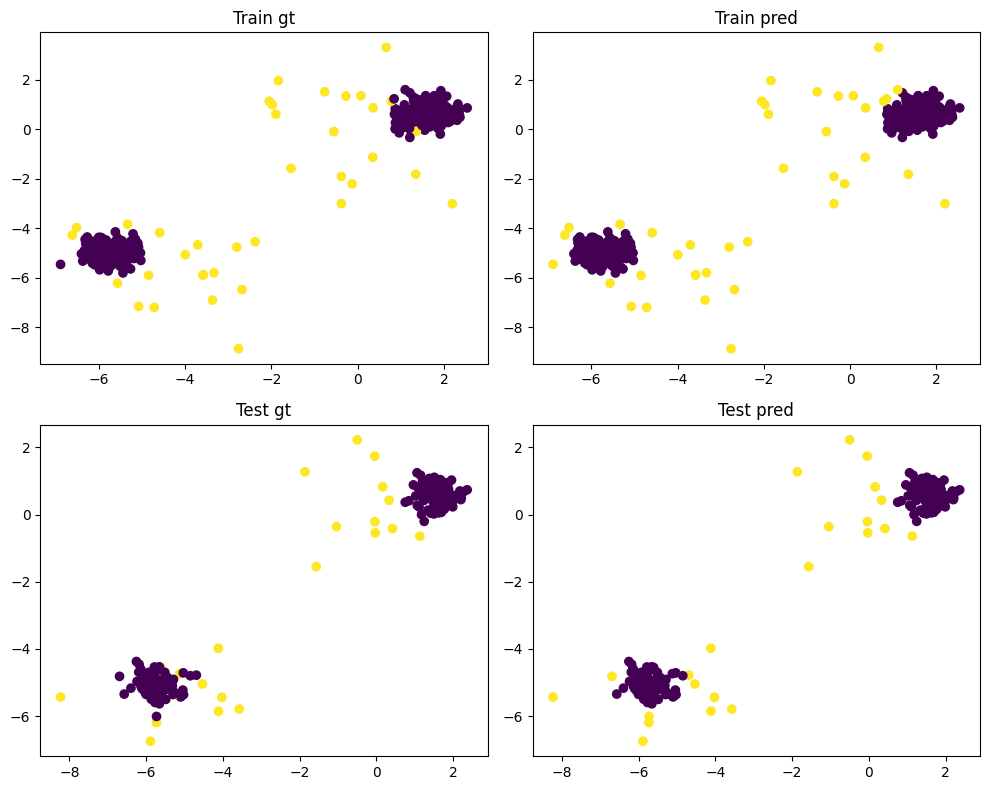

In [126]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].scatter(X_train[:, 0], X_train[:, 1], c=y_train)
axes[0, 0].set_title("Train gt")

axes[0, 1].scatter(X_train[:, 0], X_train[:, 1], c=train_preds)
axes[0, 1].set_title("Train pred")

axes[1, 0].scatter(X_test[:, 0], X_test[:, 1], c=y_test)
axes[1, 0].set_title("Test gt")

axes[1, 1].scatter(X_test[:, 0], X_test[:, 1], c=test_preds)
axes[1, 1].set_title("Test pred")

plt.tight_layout()
plt.show()


In [127]:
# ex 3:
from pyod.models.lof import LOF
from sklearn.datasets import make_blobs

knn = KNN(contamination=0.07)
lof = LOF(contamination=0.07)

X, y = make_blobs(n_samples=[200, 100], centers=[[-10, -10], [10, 10]], cluster_std=[2, 6])

In [128]:
knn.fit(X)
lof.fit(X)

preds_knn = knn.predict(X)
preds_lof = lof.predict(X)

Text(0.5, 1.0, 'LOF')

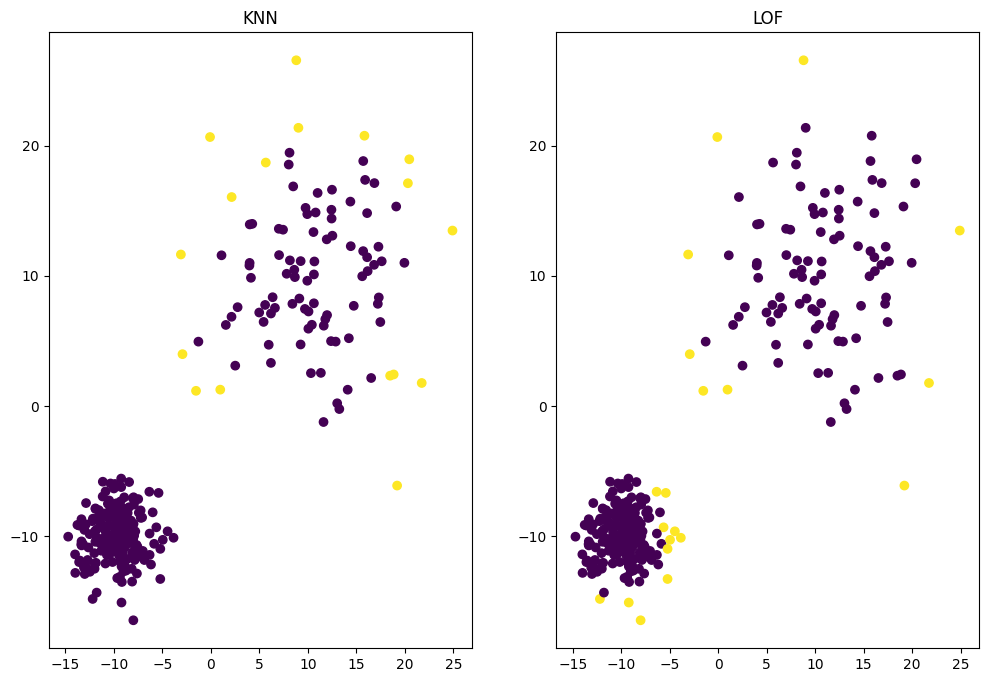

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].scatter(X[:, 0], X[:, 1], c=preds_knn)
axes[0].set_title('KNN')


axes[1].scatter(X[:, 0], X[:, 1], c=preds_lof)
axes[1].set_title('LOF')

In [130]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from pyod.models.knn import KNN
from sklearn.preprocessing import StandardScaler
import numpy as np

dataset = loadmat('cardio.mat')

X_train, X_test, y_train, y_test = train_test_split(dataset['X'], dataset['y'], random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
cont_rate = len(np.where(dataset['y'] == 1)[0]) / len(dataset['y'])

models = []
train_scores, test_scores = [], []
for i in range(30, 120, 9):
    print("STARTING KNN WITH NUM NEIS", i)
    knn = KNN(n_neighbors=i, contamination=cont_rate)
    knn.fit(X_train)
    
    train_preds = knn.predict(X_train)
    test_preds = knn.predict(X_test)
    print("BAC_TRAIN:", balanced_accuracy_score(y_train, train_preds), "\nBAC_TEST:", balanced_accuracy_score(y_test, test_preds))
    train_scores.append(knn.decision_scores_)
    test_scores.append(knn.decision_function(X_test))

    
    

STARTING KNN WITH NUM NEIS 30
BAC_TRAIN: 0.6738077309236947 
BAC_TEST: 0.7212906504065041
STARTING KNN WITH NUM NEIS 39
BAC_TRAIN: 0.6902359437751004 
BAC_TEST: 0.7629573170731707
STARTING KNN WITH NUM NEIS 48
BAC_TRAIN: 0.7062625502008032 
BAC_TEST: 0.7629573170731707
STARTING KNN WITH NUM NEIS 57
BAC_TRAIN: 0.7187845130522088 
BAC_TEST: 0.752540650406504
STARTING KNN WITH NUM NEIS 66
BAC_TRAIN: 0.7230923694779117 
BAC_TEST: 0.7929878048780488
STARTING KNN WITH NUM NEIS 75
BAC_TRAIN: 0.7269986194779117 
BAC_TEST: 0.7929878048780488
STARTING KNN WITH NUM NEIS 84
BAC_TRAIN: 0.7317080823293173 
BAC_TEST: 0.7929878048780488
STARTING KNN WITH NUM NEIS 93
BAC_TRAIN: 0.73601593875502 
BAC_TEST: 0.7917682926829268
STARTING KNN WITH NUM NEIS 102
BAC_TRAIN: 0.7446316516064257 
BAC_TEST: 0.8046239837398375
STARTING KNN WITH NUM NEIS 111
BAC_TRAIN: 0.7364175451807229 
BAC_TEST: 0.8046239837398375


In [131]:
import numpy as np
train_scores = np.array(train_scores)
test_scores = np.array(test_scores)
print(train_scores.shape)

(10, 1373)


In [132]:
from pyod.utils.utility import standardizer
train_scores_standardized = standardizer(train_scores.T)
test_scores_standardized = standardizer(test_scores.T)
print(train_scores_standardized.shape)

(1373, 10)


In [133]:
from pyod.models.combination import average, maximization

avg_train, max_train = average(train_scores_standardized), maximization(train_scores_standardized)
avg_test, max_test = average(test_scores_standardized), maximization(test_scores_standardized)
print(avg_train.shape, max_train.shape)
print(avg_test.shape, max_test.shape)

(1373,) (1373,)
(458,) (458,)


In [134]:
avg_strat_thresh = np.quantile(avg_train, 1 - cont_rate)
max_strat_thresh = np.quantile(max_train, 1 - cont_rate)

preds_avg = (avg_test > avg_strat_thresh).astype(int)
preds_max = (max_test > max_strat_thresh).astype(int)

print("BAC_AVG:", balanced_accuracy_score(y_test, preds_avg))
print("BAC_MAX", balanced_accuracy_score(y_test, preds_max))

BAC_AVG: 0.7617378048780488
BAC_MAX 0.7733739837398375
